<h2> Лабораторна робота №4 “Класифікація” </h2>

<h3>1. Завантаження та підготовка даних</h3>
<ol>
    <li>Викачати датасет Titanic із Kaggle.</li>
    <li>Завантажити файл train.csv у DataFrame.</li>
    <li>Вивести загальну інформацію про дані, перевірити наявність пропущених значень.</li>
    <li>Заповнити пропущені значення.</li>
    <li>Перетворити категоріальні ознаки у числовий формат.</li>

</ol>

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [4]:
df = pd.read_csv('train.csv')

print("--- Загальна інформація ---")
df.info()
print("\n--- Кількість пропущених значень ---")
print(df.isnull().sum())

--- Загальна інформація ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

--- Кількість пропущених значень ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Ca

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop('Cabin', axis=1, inplace=True)

print("Пропуски після обробки:")
print(df[['Age', 'Embarked']].isnull().sum())

Пропуски після обробки:
Age         0
Embarked    0
dtype: int64


In [6]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print("\nОновлений вигляд даних (перші 5 рядків):")
print(df.head())


Оновлений вигляд даних (перші 5 рядків):
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


<h3>2. Поділ даних на навчальну та тестову вибірки</h3>
<ol>
    <li>Виконати поділ даних на train/test.</li>
    <li>Вивести розміри навчальної та тестової вибірок.</li>
</ol>

In [9]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір повної вибірки ознак: {X.shape}")
print(f"Розмір навчальної вибірки (X_train): {X_train.shape}")
print(f"Розмір тестової вибірки (X_test): {X_test.shape}")
print(f"Розмір навчальних міток (y_train): {y_train.shape}")

Розмір повної вибірки ознак: (891, 8)
Розмір навчальної вибірки (X_train): (712, 8)
Розмір тестової вибірки (X_test): (179, 8)
Розмір навчальних міток (y_train): (712,)


<h3>3. Побудова класифікатора на основі дерев рішень</h3>
<ol>
    <li>Навчити модель дерева рішень на навчальних даних.</li>
    <li>Отримати класифікацію для тестової вибірки.</li>
    <li>Проаналізувати глибину дерева та кількість вузлів.</li>
</ol>

In [11]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Фактична глибина дерева: {clf.get_depth()}")
print(f"Кількість вузлів (листків): {clf.get_n_leaves()}")

result_comparison = pd.DataFrame({'Реальні': y_test[:10].values, 'Прогноз': y_pred[:10]})
print("\nПорівняння прогнозів (перші 10):")
print(result_comparison)

Фактична глибина дерева: 3
Кількість вузлів (листків): 8

Порівняння прогнозів (перші 10):
   Реальні  Прогноз
0        1        0
1        0        0
2        0        0
3        1        1
4        1        1
5        1        1
6        1        1
7        0        0
8        1        1
9        1        1


<h3>4. Оцінювання якості класифікації</h3>
<ol>
    <li>Обчислити основні метрики класифікації:</li>
    <ol>
        <li>Accuracy;</li>
        <li>Precision;</li>
        <li>Recall;</li>
        <li>F1-score.</li>
    </ol>
    <li>Побудувати confusion matrix.</li>
    <li>Вивести детальний звіт класифікації (classification_report).</li>
    <li>Проаналізувати баланс класів та пояснити, які метрики є більш інформативними для цього завдання.</li>
</ol>

Метрики класифікації:
1. Accuracy: 0.7989
2. Precision: 0.7969
3. Recall: 0.6892
4. F1-score: 0.7391


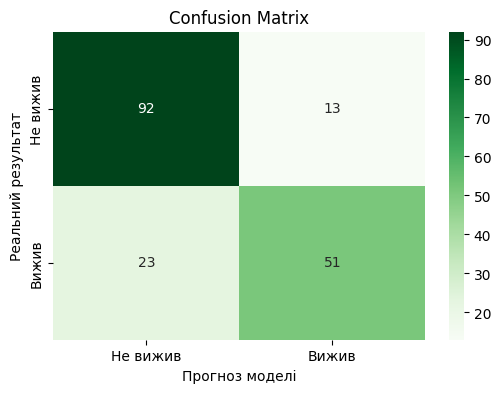


Детальний звіт (Classification Report):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Метрики класифікації:")
print(f"1. Accuracy: {accuracy:.4f}")
print(f"2. Precision: {precision:.4f}")
print(f"3. Recall: {recall:.4f}")
print(f"4. F1-score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Не вижив', 'Вижив'], 
            yticklabels=['Не вижив', 'Вижив'])
plt.xlabel('Прогноз моделі')
plt.ylabel('Реальний результат')
plt.title('Confusion Matrix')
plt.show()

print("\nДетальний звіт (Classification Report):")
print(classification_report(y_test, y_pred))

<h3>5. Інтерпретація моделі</h3>
<ol>
    <li>Вивести важливість ознак (feature importance), отриману з дерева рішень.</li>
    <li>Проаналізувати, які характеристики пасажирів найбільше впливають на ймовірність виживання.</li>
    <li>Візуалізувати дерево рішень</li>
</ol>

Важливість ознак:
       Ознака  Важливість
1         Sex    0.605737
0      Pclass    0.209536
2         Age    0.075353
5        Fare    0.061240
3       SibSp    0.048135
4       Parch    0.000000
6  Embarked_Q    0.000000
7  Embarked_S    0.000000


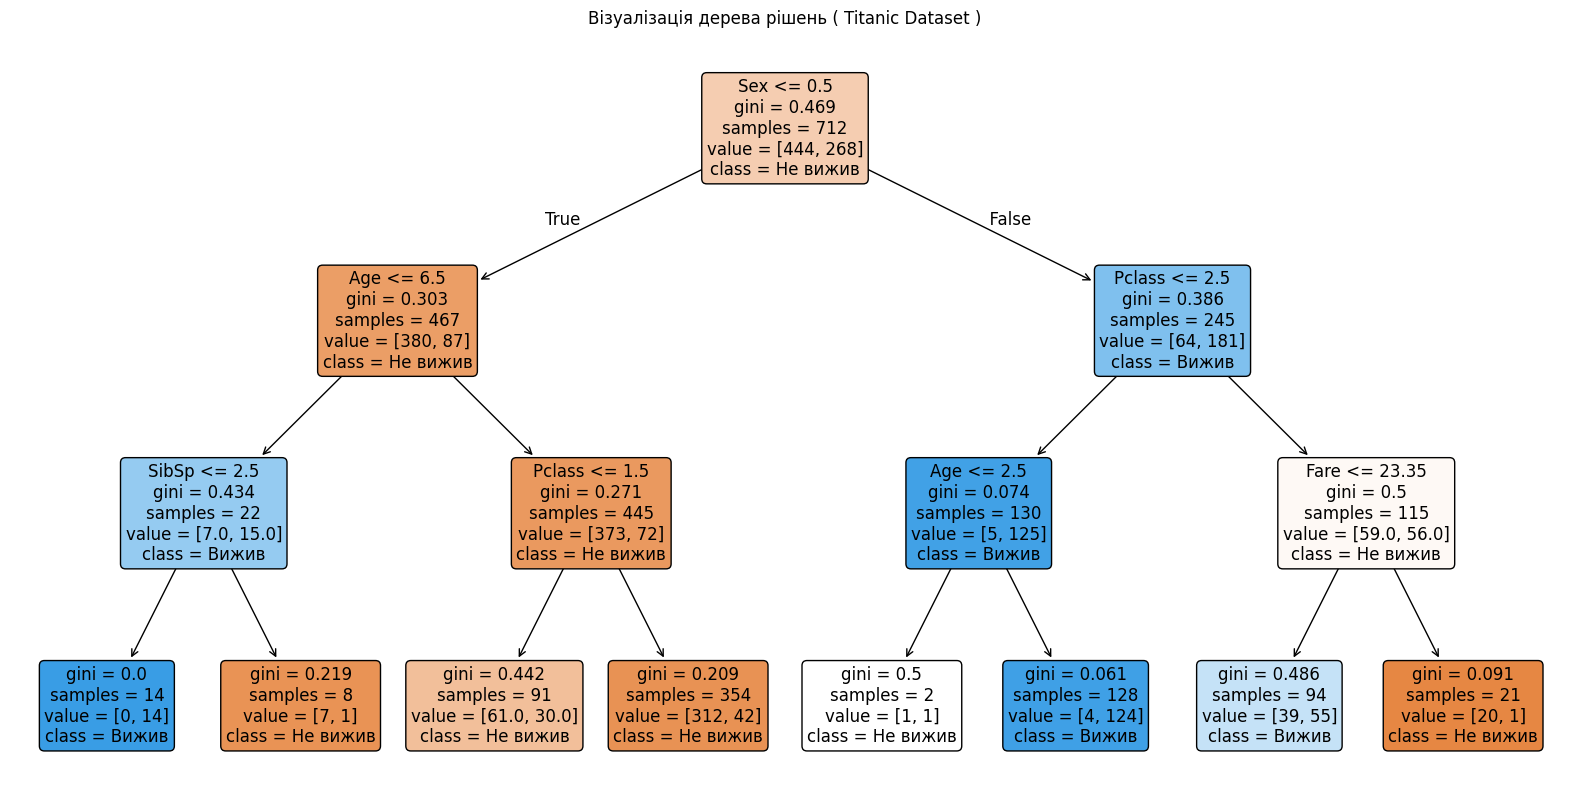

In [16]:
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Ознака': feature_names, 'Важливість': importances})
feature_importance_df = feature_importance_df.sort_values(by='Важливість', ascending=False)

print("Важливість ознак:")
print(feature_importance_df)

plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=feature_names, 
          class_names=['Не вижив', 'Вижив'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Візуалізація дерева рішень ( Titanic Dataset )")
plt.show()